# SupCon GNN Prototype

This notebook trains a simplified GNN encoder with Supervised Contrastive Loss on PKS vs non-PKS molecules.

**Goals:**
1. Verify the SupCon loss decreases (learning signal works)
2. Evaluate downstream classification via linear probe
3. Compare to fingerprint baseline

**Architecture:**
- 3 GAT layers, 4 heads each
- 256 hidden dim, 128 embedding dim, 64 projection dim
- Residual connections + LayerNorm
- Mean pooling for graph-level representation

## Cell 1: Imports and Configuration

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdchem
RDLogger.DisableLog("rdApp.*")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, accuracy_score, f1_score

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 200
LR = 3e-4
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.07
HIDDEN_DIM = 256
EMBED_DIM = 128
PROJ_DIM = 64
GAT_LAYERS = 3
GAT_HEADS = 4
DROPOUT = 0.1
SAMPLE_TRIPLETS = 10000
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Cell 2: Graph Featurization

Reusing the atom/bond featurization scheme from the existing GNN classifier.

In [16]:
# Atom feature vocabularies
ATOM_TYPES = [1, 5, 6, 7, 8, 9, 14, 15, 16, 17, 35, 53]  # [H, B, C, N, O, F, Si, P, S, Cl, Br, I]
DEGREES = [0, 1, 2, 3, 4, 5]
FORMAL_CHARGES = [-2, -1, 0, 1, 2]
NUM_HS = [0, 1, 2, 3, 4]
HYBRIDIZATIONS = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
    rdchem.HybridizationType.SP3D,
    rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    rdchem.BondType.SINGLE,
    rdchem.BondType.DOUBLE,
    rdchem.BondType.TRIPLE,
    rdchem.BondType.AROMATIC,
]

def _build_mapping(values: Iterable) -> Dict:
    return {value: idx for idx, value in enumerate(values)}

ATOM_MAP = _build_mapping(ATOM_TYPES)
DEGREE_MAP = _build_mapping(DEGREES)
CHARGE_MAP = _build_mapping(FORMAL_CHARGES)
NUM_H_MAP = _build_mapping(NUM_HS)
HYB_MAP = {hyb: idx for idx, hyb in enumerate(HYBRIDIZATIONS)}
BOND_MAP = {bond: idx for idx, bond in enumerate(BOND_TYPES)}

EDGE_FEAT_DIM = len(BOND_TYPES) + 1  # +1 for self-loop

def _one_hot(value, mapping: Dict) -> np.ndarray:
    """Create one-hot vector with unknown bucket."""
    size = len(mapping) + 1
    vec = np.zeros(size, dtype=np.float32)
    vec[mapping.get(value, len(mapping))] = 1.0
    return vec

def atom_to_feature(atom: rdchem.Atom) -> np.ndarray:
    """Convert RDKit atom to feature vector (35 dim)."""
    feats = [
        _one_hot(atom.GetAtomicNum(), ATOM_MAP),        # 13 dim
        _one_hot(atom.GetTotalDegree(), DEGREE_MAP),    # 7 dim
        _one_hot(atom.GetFormalCharge(), CHARGE_MAP),   # 6 dim
        _one_hot(atom.GetTotalNumHs(includeNeighbors=True), NUM_H_MAP),  # 6 dim
        _one_hot(atom.GetHybridization(), HYB_MAP),     # 6 dim
        np.array([atom.GetIsAromatic()], dtype=np.float32),  # 1 dim
        np.array([atom.IsInRing()], dtype=np.float32),       # 1 dim
    ]
    return np.concatenate(feats, axis=0)

def bond_to_feature(bond) -> np.ndarray:
    """Convert RDKit bond to feature vector (5 dim)."""
    vec = np.zeros(EDGE_FEAT_DIM, dtype=np.float32)
    if bond is None:
        vec[-1] = 1.0  # self-loop marker
    else:
        vec[BOND_MAP.get(bond.GetBondType(), EDGE_FEAT_DIM - 1)] = 1.0
    return vec

def smiles_to_graph(smiles: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert SMILES to graph tensors.
    
    Returns:
        node_feat: [num_atoms, node_feat_dim]
        edge_index: [2, num_edges] (includes self-loops)
        edge_attr: [num_edges, edge_feat_dim]
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    n = mol.GetNumAtoms()
    if n == 0:
        raise ValueError(f"SMILES with no atoms: {smiles}")

    # Node features
    node_feat = np.vstack([atom_to_feature(atom) for atom in mol.GetAtoms()]).astype(np.float32)
    
    # Edge features (bidirectional + self-loops)
    edges: List[Tuple[int, int]] = []
    edge_feat: List[np.ndarray] = []
    for bond in mol.GetBonds():
        u, v = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = bond_to_feature(bond)
        edges.append((u, v))
        edges.append((v, u))
        edge_feat.append(feat)
        edge_feat.append(feat)
    
    # Self-loops
    loop = bond_to_feature(None)
    for i in range(n):
        edges.append((i, i))
        edge_feat.append(loop)
    
    edge_index = np.array(edges, dtype=np.int64).T
    edge_attr = np.vstack(edge_feat).astype(np.float32)
    return node_feat, edge_index, edge_attr

# Test featurization
test_smiles = "CCO"
nf, ei, ea = smiles_to_graph(test_smiles)
print(f"Test SMILES: {test_smiles}")
print(f"Node features shape: {nf.shape}")
print(f"Edge index shape: {ei.shape}")
print(f"Edge attr shape: {ea.shape}")
NODE_FEAT_DIM = nf.shape[1]
print(f"\nNode feature dim: {NODE_FEAT_DIM}")
print(f"Edge feature dim: {EDGE_FEAT_DIM}")

Test SMILES: CCO
Node features shape: (3, 40)
Edge index shape: (2, 7)
Edge attr shape: (7, 5)

Node feature dim: 40
Edge feature dim: 5


## Cell 3: Dataset and DataLoader

In [17]:
@dataclass
class GraphSample:
    """Container for a single molecular graph."""
    node_feat: np.ndarray
    edge_index: np.ndarray
    edge_attr: np.ndarray
    label: int


class MolecularGraphDataset(Dataset):
    """Dataset that samples triplets and converts SMILES to graphs on-the-fly."""
    
    def __init__(self, parquet_path: str, num_triplets: int = None, seed: int = SEED):
        df = pd.read_parquet(parquet_path)
        
        if num_triplets is not None:
            # Sample a subset of triplets
            unique_triplets = df['triplet_id'].unique()
            rng = np.random.default_rng(seed)
            sampled_triplets = rng.choice(
                unique_triplets, 
                size=min(num_triplets, len(unique_triplets)), 
                replace=False
            )
            df = df[df['triplet_id'].isin(sampled_triplets)].reset_index(drop=True)
        
        self.smiles = df['smiles'].astype(str).tolist()
        self.labels = df['label'].to_numpy().astype(np.int64)
        
        # Get feature dimensions from first valid molecule
        for smi in self.smiles:
            try:
                nf, _, ea = smiles_to_graph(smi)
                self.node_feat_dim = nf.shape[1]
                self.edge_feat_dim = ea.shape[1]
                break
            except ValueError:
                continue
        else:
            raise RuntimeError("No valid molecules found")
    
    def __len__(self) -> int:
        return len(self.smiles)
    
    def __getitem__(self, idx: int) -> GraphSample:
        nf, ei, ea = smiles_to_graph(self.smiles[idx])
        return GraphSample(nf, ei, ea, int(self.labels[idx]))


def collate_graphs(batch: List[GraphSample]) -> Dict[str, torch.Tensor]:
    """Collate graphs into a batched format."""
    node_feats = []
    edge_indices = []
    edge_attrs = []
    batch_index = []
    labels = []
    offset = 0
    
    for graph in batch:
        x = torch.from_numpy(graph.node_feat)
        ei = torch.from_numpy(graph.edge_index) + offset
        ea = torch.from_numpy(graph.edge_attr)
        n = x.size(0)
        
        node_feats.append(x)
        edge_indices.append(ei)
        edge_attrs.append(ea)
        batch_index.append(torch.full((n,), len(labels), dtype=torch.long))
        labels.append(graph.label)
        offset += n
    
    return {
        'node_feat': torch.cat(node_feats, dim=0),
        'edge_index': torch.cat(edge_indices, dim=1),
        'edge_attr': torch.cat(edge_attrs, dim=0),
        'batch': torch.cat(batch_index, dim=0),
        'labels': torch.tensor(labels, dtype=torch.long),
    }


# Load datasets
print("Loading training data...")
train_ds = MolecularGraphDataset(
    '../data/train/supcon_train.parquet',
    num_triplets=SAMPLE_TRIPLETS,
    seed=SEED
)

print("Loading validation data...")
val_ds = MolecularGraphDataset(
    '../data/val/supcon_val.parquet',
    num_triplets=200,  # Small validation set
    seed=SEED
)

print(f"\nTrain samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print(f"Train label distribution: {np.bincount(train_ds.labels)}")
print(f"Val label distribution: {np.bincount(val_ds.labels)}")

# Create data loaders
train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_graphs,
    num_workers=0
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_graphs,
    num_workers=0
)

Loading training data...
Loading validation data...

Train samples: 30000
Val samples: 600
Train label distribution: [20000 10000]
Val label distribution: [400 200]


## Cell 4: GNN Encoder Architecture

Simplified GAT encoder with:
- 3 layers, 4 heads each
- Residual connections + LayerNorm
- Edge features in attention
- Mean pooling -> embedding head -> projection head

In [18]:
def edge_softmax(dst: torch.Tensor, scores: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Compute softmax over edges grouped by destination node.
    
    Args:
        dst: [num_edges] destination node indices
        scores: [num_edges, heads] attention scores
        num_nodes: total number of nodes
    
    Returns:
        [num_edges, heads] attention weights (softmaxed per dst node)
    """
    heads = scores.size(1)
    out = []
    for h in range(heads):
        s = scores[:, h]
        # Compute max per destination for numerical stability
        max_vals = torch.full((num_nodes,), -float('inf'), device=s.device)
        max_vals.scatter_reduce_(0, dst, s, reduce='amax')
        s = s - max_vals[dst]
        exp_s = torch.exp(s)
        # Sum per destination
        denom = torch.zeros(num_nodes, device=s.device).scatter_add_(0, dst, exp_s)
        out.append(exp_s / (denom[dst] + 1e-16))
    return torch.stack(out, dim=1)


class GraphAttentionLayer(nn.Module):
    """Single GAT layer with edge features."""
    
    def __init__(self, in_dim: int, out_dim: int, heads: int, edge_dim: int, dropout: float = 0.0):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        
        self.lin = nn.Linear(in_dim, out_dim * heads, bias=False)
        self.att_src = nn.Parameter(torch.Tensor(heads, out_dim))
        self.att_dst = nn.Parameter(torch.Tensor(heads, out_dim))
        self.bias = nn.Parameter(torch.Tensor(out_dim))
        self.edge_proj = nn.Linear(edge_dim, heads, bias=False)
        self.dropout = dropout
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)
        nn.init.xavier_uniform_(self.edge_proj.weight)
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        """Forward pass.
        
        Args:
            x: [num_nodes, in_dim] node features
            edge_index: [2, num_edges] edge indices
            edge_attr: [num_edges, edge_dim] edge features
        
        Returns:
            [num_nodes, out_dim] updated node features
        """
        h = self.lin(x)  # [N, heads * out_dim]
        num_nodes = h.size(0)
        h = h.view(num_nodes, self.heads, self.out_dim)  # [N, heads, out_dim]
        
        # Attention scores
        att_src = (h * self.att_src).sum(dim=-1)  # [N, heads]
        att_dst = (h * self.att_dst).sum(dim=-1)  # [N, heads]
        
        src, dst = edge_index
        edge_logits = att_src[src] + att_dst[dst] + self.edge_proj(edge_attr)  # [E, heads]
        edge_logits = F.leaky_relu(edge_logits, 0.2)
        
        # Softmax attention
        edge_alpha = edge_softmax(dst, edge_logits, num_nodes)  # [E, heads]
        edge_alpha = F.dropout(edge_alpha, p=self.dropout, training=self.training)
        
        # Aggregate
        out = h[src] * edge_alpha.unsqueeze(-1)  # [E, heads, out_dim]
        agg = torch.zeros(num_nodes, self.heads, self.out_dim, device=x.device)
        agg.index_add_(0, dst, out)
        
        return agg.mean(dim=1) + self.bias  # [N, out_dim]


class SupConGNNEncoder(nn.Module):
    """GNN encoder for Supervised Contrastive Learning.
    
    Architecture:
    - Input projection: node_dim -> hidden_dim
    - GAT layers with residual + LayerNorm
    - Mean pooling over nodes
    - Embedding head: hidden_dim -> embed_dim (produces g)
    - Projection head: embed_dim -> proj_dim (produces z)
    """
    
    def __init__(
        self, 
        node_dim: int, 
        edge_dim: int, 
        hidden_dim: int = 256, 
        heads: int = 4, 
        num_layers: int = 3,
        embed_dim: int = 128, 
        proj_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Input projection
        self.input_proj = nn.Linear(node_dim, hidden_dim)
        
        # GAT layers with LayerNorm
        self.gat_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.gat_layers.append(
                GraphAttentionLayer(hidden_dim, hidden_dim, heads, edge_dim, dropout)
            )
            self.layer_norms.append(nn.LayerNorm(hidden_dim))
        
        self.dropout = dropout
        
        # Embedding head (produces g)
        self.embed_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, embed_dim),
        )
        
        # Projection head (produces z, discarded after pretraining)
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, proj_dim),
        )
    
    def forward(
        self, 
        node_feat: torch.Tensor, 
        edge_index: torch.Tensor, 
        batch: torch.Tensor, 
        edge_attr: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Forward pass.
        
        Args:
            node_feat: [total_nodes, node_dim] batched node features
            edge_index: [2, total_edges] batched edge indices
            batch: [total_nodes] node-to-graph assignment
            edge_attr: [total_edges, edge_dim] batched edge features
        
        Returns:
            g: [batch_size, embed_dim] graph embeddings (for downstream tasks)
            z: [batch_size, proj_dim] projections (for contrastive loss)
        """
        # Input projection
        x = self.input_proj(node_feat)
        
        # GAT layers with residual + LayerNorm
        for gat, norm in zip(self.gat_layers, self.layer_norms):
            residual = x
            x = gat(x, edge_index, edge_attr)
            x = norm(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual  # Residual connection
        
        # Mean pooling over nodes
        num_graphs = int(batch.max().item()) + 1 if batch.numel() > 0 else 0
        graph_embed = torch.zeros(num_graphs, self.hidden_dim, device=x.device)
        counts = torch.zeros(num_graphs, device=x.device)
        graph_embed.index_add_(0, batch, x)
        counts.index_add_(0, batch, torch.ones_like(batch, dtype=x.dtype))
        graph_embed = graph_embed / counts.clamp_min(1.0).unsqueeze(-1)
        
        # Embedding and projection heads
        g = self.embed_head(graph_embed)  # [B, embed_dim]
        g = F.normalize(g, dim=-1, eps=1e-8)  # L2 normalize embeddings
        
        z = self.proj_head(g)  # [B, proj_dim]
        z = F.normalize(z, dim=-1, eps=1e-8)  # L2 normalize projections
        
        return g, z


# Initialize model
model = SupConGNNEncoder(
    node_dim=train_ds.node_feat_dim,
    edge_dim=train_ds.edge_feat_dim,
    hidden_dim=HIDDEN_DIM,
    heads=GAT_HEADS,
    num_layers=GAT_LAYERS,
    embed_dim=EMBED_DIM,
    proj_dim=PROJ_DIM,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"\nArchitecture:")
print(f"  Input: {train_ds.node_feat_dim} -> {HIDDEN_DIM}")
print(f"  GAT layers: {GAT_LAYERS} x (hidden={HIDDEN_DIM}, heads={GAT_HEADS})")
print(f"  Embed head: {HIDDEN_DIM} -> {EMBED_DIM}")
print(f"  Proj head: {EMBED_DIM} -> {PROJ_DIM}")

Model parameters: 928,892

Architecture:
  Input: 40 -> 256
  GAT layers: 3 x (hidden=256, heads=4)
  Embed head: 256 -> 128
  Proj head: 128 -> 64


## Cell 5: SupCon Loss

In [19]:
class SupConLoss(nn.Module):
    """Supervised Contrastive Loss.
    
    For each anchor, pull together samples with the same label
    and push apart samples with different labels.
    """
    
    def __init__(self, temperature: float = 0.07, eps: float = 1e-8):
        super().__init__()
        self.tau = temperature
        self.eps = eps
    
    def forward(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """Compute SupCon loss.
        
        Args:
            z: [B, proj_dim] L2-normalized projections
            labels: [B] class labels
        
        Returns:
            Scalar loss
        """
        B = z.size(0)
        z = F.normalize(z.float(), dim=-1, eps=self.eps)  # Ensure normalized
        
        # Similarity matrix scaled by temperature
        sim = (z @ z.t()) / self.tau  # [B, B]
        
        # Masks
        eye = torch.eye(B, dtype=torch.bool, device=z.device)
        labels = labels.view(-1, 1)
        pos_mask = (labels == labels.t()) & (~eye)  # Same class, not self
        
        # Skip anchors with no positives
        valid_mask = pos_mask.sum(1) > 0
        if not valid_mask.any():
            return torch.tensor(0.0, device=z.device, requires_grad=True)
        
        # Restrict to valid anchors
        sim = sim[valid_mask]
        pos_mask = pos_mask[valid_mask]
        eye_valid = eye[valid_mask]
        
        # Numerical stability: subtract max
        sim = sim - sim.max(dim=1, keepdim=True).values
        
        # Mask out self-similarities for denominator
        sim_masked = sim.masked_fill(eye_valid, float('-inf'))
        
        # Log-softmax denominator (excluding self)
        denom = torch.logsumexp(sim_masked, dim=1, keepdim=True)
        log_prob = sim - denom
        
        # Average log-prob over positives
        pos_counts = pos_mask.sum(1).clamp_min(1)
        pos_log_prob = (pos_mask * log_prob).sum(1) / pos_counts
        
        loss = -pos_log_prob.mean()
        
        if not torch.isfinite(loss):
            print("Warning: SupConLoss produced non-finite value")
            return torch.tensor(0.0, device=z.device, requires_grad=True)
        
        return loss


# Test loss computation
criterion = SupConLoss(temperature=TEMPERATURE).to(device)

# Test with dummy data
z_test = F.normalize(torch.randn(8, PROJ_DIM, device=device), dim=-1)
labels_test = torch.tensor([0, 0, 0, 1, 1, 1, 0, 1], device=device)
loss_test = criterion(z_test, labels_test)
print(f"Test loss: {loss_test.item():.4f}")

Test loss: 3.5699


## Cell 6: Training Loop

In [20]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch in loader:
        node_feat = batch['node_feat'].to(device)
        edge_index = batch['edge_index'].to(device)
        edge_attr = batch['edge_attr'].to(device)
        batch_idx = batch['batch'].to(device)
        labels = batch['labels'].to(device)
        
        # Skip batches with only one class (no positives for the other)
        if labels.unique().numel() < 2:
            continue
        
        optimizer.zero_grad()
        
        g, z = model(node_feat, edge_index, batch_idx, edge_attr)
        loss = criterion(z, labels)
        
        if not torch.isfinite(loss):
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / max(num_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """Evaluate loss on a dataset."""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    for batch in loader:
        node_feat = batch['node_feat'].to(device)
        edge_index = batch['edge_index'].to(device)
        edge_attr = batch['edge_attr'].to(device)
        batch_idx = batch['batch'].to(device)
        labels = batch['labels'].to(device)
        
        if labels.unique().numel() < 2:
            continue
        
        g, z = model(node_feat, edge_index, batch_idx, edge_attr)
        loss = criterion(z, labels)
        
        if torch.isfinite(loss):
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / max(num_batches, 1)


# Setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Training
print("Starting training...")
print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 32)

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>12.4f}")

print("\nTraining complete!")

Starting training...
Epoch   Train Loss     Val Loss
--------------------------------
    1       4.1425       4.0423
    2       4.1424       4.0424
    3       4.1422       4.0414
    4       4.1198       4.0364
    5       4.0622       3.9129
    6       4.0082       3.8722
    7       3.9830       3.8004
    8       3.9507       3.7615
    9       3.9320       3.7299
   10       3.9217       3.7703
   11       3.8954       3.7011
   12       3.8843       3.6522
   13       3.8581       3.6223
   14       3.8395       3.6337
   15       3.8317       3.6618
   16       3.8217       3.6402
   17       3.8163       3.6449
   18       3.8001       3.6678
   19       3.8016       3.6067
   20       3.7909       3.5637
   21       3.7854       3.5554
   22       3.7751       3.6298
   23       3.7730       3.5907
   24       3.7709       3.6138
   25       3.7682       3.6260
   26       3.7592       3.5919
   27       3.7617       3.5713
   28       3.7557       3.6216
   29       3.7461

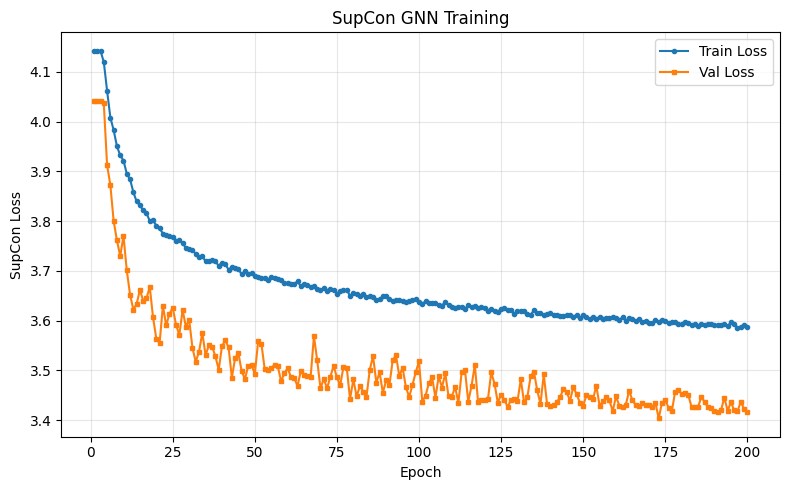


Final train loss: 3.5877
Final val loss: 3.4174
Best val loss: 3.4038 (epoch 173)


In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o', markersize=3)
ax.plot(range(1, EPOCHS + 1), val_losses, label='Val Loss', marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('SupCon Loss')
ax.set_title('SupCon GNN Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Best val loss: {min(val_losses):.4f} (epoch {val_losses.index(min(val_losses)) + 1})")

## Cell 7: Linear Probe Evaluation

Extract embeddings from the trained GNN and train a logistic regression classifier.

In [22]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Extract graph embeddings (g, not z) for all samples."""
    model.eval()
    embeddings = []
    labels = []
    
    for batch in loader:
        node_feat = batch['node_feat'].to(device)
        edge_index = batch['edge_index'].to(device)
        edge_attr = batch['edge_attr'].to(device)
        batch_idx = batch['batch'].to(device)
        
        g, _ = model(node_feat, edge_index, batch_idx, edge_attr)
        embeddings.append(g.cpu().numpy())
        labels.append(batch['labels'].numpy())
    
    return np.vstack(embeddings), np.concatenate(labels)


# Extract embeddings
print("Extracting embeddings...")
train_embeds, train_labels = extract_embeddings(model, train_loader, device)
val_embeds, val_labels = extract_embeddings(model, val_loader, device)

print(f"Train embeddings: {train_embeds.shape}")
print(f"Val embeddings: {val_embeds.shape}")

# Train linear classifier
print("\nTraining linear probe...")
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf.fit(train_embeds, train_labels)

# Evaluate
train_pred = clf.predict(train_embeds)
train_prob = clf.predict_proba(train_embeds)[:, 1]
val_pred = clf.predict(val_embeds)
val_prob = clf.predict_proba(val_embeds)[:, 1]

print("\n--- Linear Probe Results (GNN Embeddings) ---")
print(f"Train Accuracy: {accuracy_score(train_labels, train_pred):.4f}")
print(f"Train AUPRC: {average_precision_score(train_labels, train_prob):.4f}")
print(f"Train F1: {f1_score(train_labels, train_pred):.4f}")
print()
print(f"Val Accuracy: {accuracy_score(val_labels, val_pred):.4f}")
print(f"Val AUPRC: {average_precision_score(val_labels, val_prob):.4f}")
print(f"Val F1: {f1_score(val_labels, val_pred):.4f}")

Extracting embeddings...
Train embeddings: (30000, 128)
Val embeddings: (600, 128)

Training linear probe...

--- Linear Probe Results (GNN Embeddings) ---
Train Accuracy: 0.9888
Train AUPRC: 0.9991
Train F1: 0.9834

Val Accuracy: 0.9917
Val AUPRC: 0.9997
Val F1: 0.9877


## Cell 8: Comparison with Fingerprint Baseline

Compare GNN embeddings to ECFP4 fingerprints on the same molecules.

In [23]:
from rdkit.Chem import AllChem

def smiles_to_ecfp4(smiles: str, nbits: int = 2048) -> np.ndarray:
    """Convert SMILES to ECFP4 fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nbits, dtype=np.float32)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=nbits)
    return np.array(fp, dtype=np.float32)


# Generate fingerprints for training data
print("Generating ECFP4 fingerprints...")
train_fps = np.vstack([smiles_to_ecfp4(smi) for smi in train_ds.smiles])
val_fps = np.vstack([smiles_to_ecfp4(smi) for smi in val_ds.smiles])

print(f"Train fingerprints: {train_fps.shape}")
print(f"Val fingerprints: {val_fps.shape}")

# Train logistic regression on fingerprints
print("\nTraining fingerprint baseline...")
clf_fp = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf_fp.fit(train_fps, train_ds.labels)

# Evaluate
train_pred_fp = clf_fp.predict(train_fps)
train_prob_fp = clf_fp.predict_proba(train_fps)[:, 1]
val_pred_fp = clf_fp.predict(val_fps)
val_prob_fp = clf_fp.predict_proba(val_fps)[:, 1]

print("\n--- Linear Probe Results (ECFP4 Fingerprints) ---")
print(f"Train Accuracy: {accuracy_score(train_ds.labels, train_pred_fp):.4f}")
print(f"Train AUPRC: {average_precision_score(train_ds.labels, train_prob_fp):.4f}")
print(f"Train F1: {f1_score(train_ds.labels, train_pred_fp):.4f}")
print()
print(f"Val Accuracy: {accuracy_score(val_ds.labels, val_pred_fp):.4f}")
print(f"Val AUPRC: {average_precision_score(val_ds.labels, val_prob_fp):.4f}")
print(f"Val F1: {f1_score(val_ds.labels, val_pred_fp):.4f}")

Generating ECFP4 fingerprints...
Train fingerprints: (30000, 2048)
Val fingerprints: (600, 2048)

Training fingerprint baseline...

--- Linear Probe Results (ECFP4 Fingerprints) ---
Train Accuracy: 0.9231
Train AUPRC: 0.9170
Train F1: 0.8932

Val Accuracy: 0.9117
Val AUPRC: 0.9026
Val F1: 0.8729


In [24]:
# Summary comparison
print("\n" + "=" * 50)
print("SUMMARY: GNN Embeddings vs ECFP4 Fingerprints")
print("=" * 50)

gnn_val_auprc = average_precision_score(val_labels, val_prob)
fp_val_auprc = average_precision_score(val_ds.labels, val_prob_fp)

gnn_val_acc = accuracy_score(val_labels, val_pred)
fp_val_acc = accuracy_score(val_ds.labels, val_pred_fp)

print(f"\n{'Metric':<20} {'GNN Embed':>12} {'ECFP4':>12} {'Diff':>10}")
print("-" * 56)
print(f"{'Val Accuracy':<20} {gnn_val_acc:>12.4f} {fp_val_acc:>12.4f} {gnn_val_acc - fp_val_acc:>+10.4f}")
print(f"{'Val AUPRC':<20} {gnn_val_auprc:>12.4f} {fp_val_auprc:>12.4f} {gnn_val_auprc - fp_val_auprc:>+10.4f}")

print("\n" + "=" * 50)
if gnn_val_auprc > fp_val_auprc:
    print("GNN embeddings OUTPERFORM fingerprints on AUPRC!")
elif gnn_val_auprc < fp_val_auprc:
    print("Fingerprints outperform GNN embeddings on AUPRC.")
    print("Consider: more epochs, larger model, or tuning temperature.")
else:
    print("GNN embeddings and fingerprints perform similarly.")


SUMMARY: GNN Embeddings vs ECFP4 Fingerprints

Metric                  GNN Embed        ECFP4       Diff
--------------------------------------------------------
Val Accuracy               0.9917       0.9117    +0.0800
Val AUPRC                  0.9997       0.9026    +0.0971

GNN embeddings OUTPERFORM fingerprints on AUPRC!


## Cell 9: t-SNE Visualization (Optional)

In [25]:
from sklearn.manifold import TSNE

# Combine train + val for visualization
all_embeds = np.vstack([train_embeds, val_embeds])
all_labels = np.concatenate([train_labels, val_labels])
all_fps = np.vstack([train_fps, val_fps])

# Subsample for faster t-SNE
max_samples = 1000
if len(all_embeds) > max_samples:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(all_embeds), size=max_samples, replace=False)
    all_embeds_sub = all_embeds[idx]
    all_labels_sub = all_labels[idx]
    all_fps_sub = all_fps[idx]
else:
    all_embeds_sub = all_embeds
    all_labels_sub = all_labels
    all_fps_sub = all_fps

print(f"Running t-SNE on {len(all_embeds_sub)} samples...")

# t-SNE on GNN embeddings
tsne_gnn = TSNE(n_components=2, random_state=SEED, perplexity=30)
gnn_2d = tsne_gnn.fit_transform(all_embeds_sub)

# t-SNE on fingerprints
tsne_fp = TSNE(n_components=2, random_state=SEED, perplexity=30)
fp_2d = tsne_fp.fit_transform(all_fps_sub)

print("t-SNE complete!")

Running t-SNE on 1000 samples...
t-SNE complete!


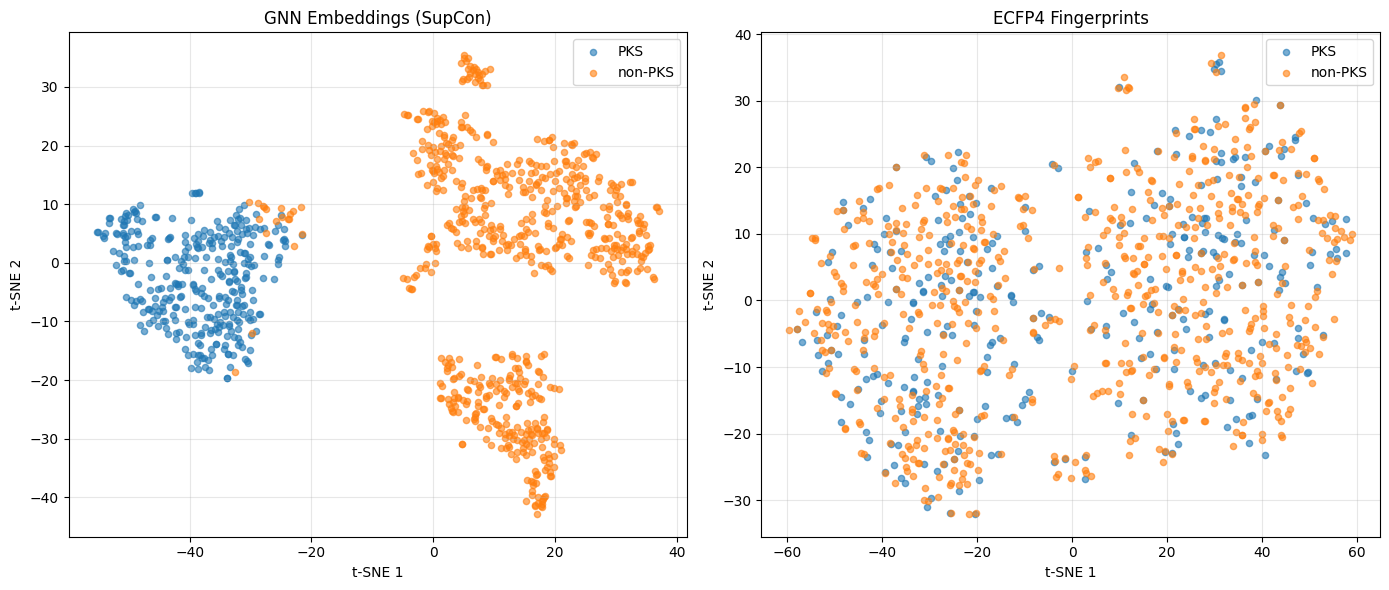


Interpretation:
- Look for separation between PKS (blue) and non-PKS (orange) clusters
- Better separation indicates more discriminative representations


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GNN embeddings
ax = axes[0]
for label, name, color in [(1, 'PKS', 'tab:blue'), (0, 'non-PKS', 'tab:orange')]:
    mask = all_labels_sub == label
    ax.scatter(gnn_2d[mask, 0], gnn_2d[mask, 1], c=color, label=name, alpha=0.6, s=20)
ax.set_title('GNN Embeddings (SupCon)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
ax.grid(True, alpha=0.3)

# Fingerprints
ax = axes[1]
for label, name, color in [(1, 'PKS', 'tab:blue'), (0, 'non-PKS', 'tab:orange')]:
    mask = all_labels_sub == label
    ax.scatter(fp_2d[mask, 0], fp_2d[mask, 1], c=color, label=name, alpha=0.6, s=20)
ax.set_title('ECFP4 Fingerprints')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Look for separation between PKS (blue) and non-PKS (orange) clusters")
print("- Better separation indicates more discriminative representations")

## Summary

### Success Criteria Check:

1. **SupCon loss decreases**: Check the training curve above
2. **Linear probe AUPRC > 0.7**: Check the evaluation results
3. **Comparison insight**: See if GNN embeddings improve over ECFP4

### Next Steps (if prototype validates):

1. Create production script `scripts/07_supcon_gnn_pretraining.py`
2. Scale to full dataset with distributed training
3. Hyperparameter tuning (temperature, architecture depth, etc.)

## Cell 10: PKS Probability Distribution Analysis

Visualize the distribution of PKS probability scores from the linear probe.
These scores represent "PKS synthesizability" - higher values indicate molecules
more likely to be PKS products.

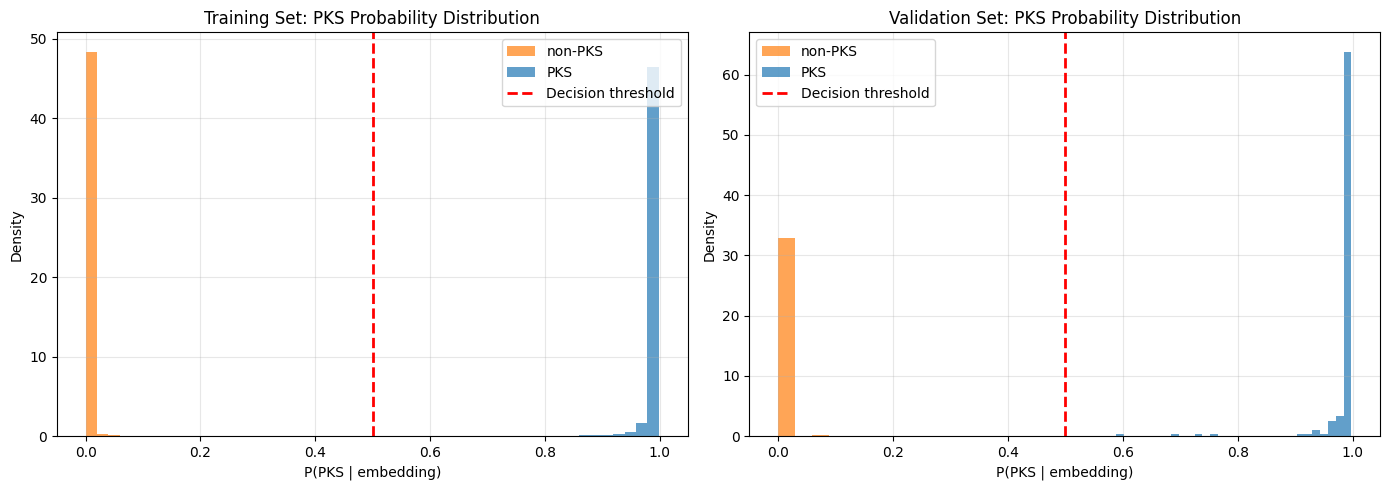


Observation: Well-separated distributions indicate the linear probe
can reliably distinguish PKS from non-PKS based on GNN embeddings.


In [27]:
# Cell 10a: Probability Distribution Histograms

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distributions
ax = axes[0]
ax.hist(train_prob[train_labels == 0], bins=50, alpha=0.7, label='non-PKS', color='tab:orange', density=True)
ax.hist(train_prob[train_labels == 1], bins=50, alpha=0.7, label='PKS', color='tab:blue', density=True)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision threshold')
ax.set_xlabel('P(PKS | embedding)')
ax.set_ylabel('Density')
ax.set_title('Training Set: PKS Probability Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation set distributions
ax = axes[1]
ax.hist(val_prob[val_labels == 0], bins=30, alpha=0.7, label='non-PKS', color='tab:orange', density=True)
ax.hist(val_prob[val_labels == 1], bins=30, alpha=0.7, label='PKS', color='tab:blue', density=True)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision threshold')
ax.set_xlabel('P(PKS | embedding)')
ax.set_ylabel('Density')
ax.set_title('Validation Set: PKS Probability Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation: Well-separated distributions indicate the linear probe")
print("can reliably distinguish PKS from non-PKS based on GNN embeddings.")

In [28]:
# Cell 10b: Summary Statistics

print("=" * 60)
print("PKS Probability Score Summary Statistics")
print("=" * 60)

# Training set stats
print("\n--- Training Set ---")
train_pks_probs = train_prob[train_labels == 1]
train_nonpks_probs = train_prob[train_labels == 0]

print(f"\nPKS molecules (n={len(train_pks_probs)}):")
print(f"  Mean:   {train_pks_probs.mean():.4f}")
print(f"  Median: {np.median(train_pks_probs):.4f}")
print(f"  Std:    {train_pks_probs.std():.4f}")
print(f"  Range:  [{train_pks_probs.min():.4f}, {train_pks_probs.max():.4f}]")

print(f"\nnon-PKS molecules (n={len(train_nonpks_probs)}):")
print(f"  Mean:   {train_nonpks_probs.mean():.4f}")
print(f"  Median: {np.median(train_nonpks_probs):.4f}")
print(f"  Std:    {train_nonpks_probs.std():.4f}")
print(f"  Range:  [{train_nonpks_probs.min():.4f}, {train_nonpks_probs.max():.4f}]")

# Validation set stats
print("\n--- Validation Set ---")
val_pks_probs = val_prob[val_labels == 1]
val_nonpks_probs = val_prob[val_labels == 0]

print(f"\nPKS molecules (n={len(val_pks_probs)}):")
print(f"  Mean:   {val_pks_probs.mean():.4f}")
print(f"  Median: {np.median(val_pks_probs):.4f}")
print(f"  Std:    {val_pks_probs.std():.4f}")
print(f"  Range:  [{val_pks_probs.min():.4f}, {val_pks_probs.max():.4f}]")

print(f"\nnon-PKS molecules (n={len(val_nonpks_probs)}):")
print(f"  Mean:   {val_nonpks_probs.mean():.4f}")
print(f"  Median: {np.median(val_nonpks_probs):.4f}")
print(f"  Std:    {val_nonpks_probs.std():.4f}")
print(f"  Range:  [{val_nonpks_probs.min():.4f}, {val_nonpks_probs.max():.4f}]")

# Class separation metric
print("\n--- Class Separation ---")
train_sep = train_pks_probs.mean() - train_nonpks_probs.mean()
val_sep = val_pks_probs.mean() - val_nonpks_probs.mean()
print(f"Train mean difference (PKS - non-PKS): {train_sep:.4f}")
print(f"Val mean difference (PKS - non-PKS):   {val_sep:.4f}")

# Overlap analysis
train_overlap_pks = (train_pks_probs < 0.5).sum()
train_overlap_nonpks = (train_nonpks_probs >= 0.5).sum()
val_overlap_pks = (val_pks_probs < 0.5).sum()
val_overlap_nonpks = (val_nonpks_probs >= 0.5).sum()

print(f"\nMisclassified at threshold=0.5:")
print(f"  Train: {train_overlap_pks} PKS below 0.5, {train_overlap_nonpks} non-PKS above 0.5")
print(f"  Val:   {val_overlap_pks} PKS below 0.5, {val_overlap_nonpks} non-PKS above 0.5")

PKS Probability Score Summary Statistics

--- Training Set ---

PKS molecules (n=10000):
  Mean:   0.9847
  Median: 0.9953
  Std:    0.0626
  Range:  [0.0025, 0.9982]

non-PKS molecules (n=20000):
  Mean:   0.0153
  Median: 0.0000
  Std:    0.1010
  Range:  [0.0000, 0.9949]

--- Validation Set ---

PKS molecules (n=200):
  Mean:   0.9843
  Median: 0.9944
  Std:    0.0440
  Range:  [0.5887, 0.9978]

non-PKS molecules (n=400):
  Mean:   0.0098
  Median: 0.0000
  Std:    0.0792
  Range:  [0.0000, 0.8931]

--- Class Separation ---
Train mean difference (PKS - non-PKS): 0.9694
Val mean difference (PKS - non-PKS):   0.9745

Misclassified at threshold=0.5:
  Train: 53 PKS below 0.5, 282 non-PKS above 0.5
  Val:   0 PKS below 0.5, 5 non-PKS above 0.5
